# Imitation Learning in MiniGrid DoorKey

This notebook builds a complete imitation-learning project around `MiniGrid-DoorKey-16x16-v0`. This larger DoorKey variant is still practical on CPU, but it gives behavior cloning much more room to drift into off-expert states.

We use three learners:

- behavior cloning (BC), trained only on expert demonstrations
- DAgger, which asks the expert to label states visited by the learner
- budgeted critical-state DAgger, which spends fewer expert labels on high-uncertainty learner states

All code lives in this notebook. Generated GIFs and plots are saved under `outputs/`.


In [1]:
# Lightweight dependency cell for Colab, Kaggle, and local notebooks.
# It only installs packages that are missing in the current kernel.
import importlib.util
import subprocess
import sys

required_packages = {
    "gymnasium": "gymnasium",
    "minigrid": "minigrid",
    "torch": "torch",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "imageio": "imageio",
    "tqdm": "tqdm",
}

missing = [pip_name for import_name, pip_name in required_packages.items()
           if importlib.util.find_spec(import_name) is None]

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are already installed.")


Installing missing packages: ['minigrid']


## Project knobs

We use moderate defaults for the larger DoorKey map. The full run is still CPU-friendly, but the larger map and longer rollouts make the imitation-learning differences easier to see.


In [2]:
import copy
import json
import math
import os
import random
from collections import deque
from dataclasses import dataclass
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import Image as IPyImage
from IPython.display import Markdown, display
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

import minigrid  # Registers MiniGrid environments with Gymnasium.
from minigrid.wrappers import ViewSizeWrapper

# Main experiment configuration.
ENV_ID = "MiniGrid-DoorKey-16x16-v0"
GRID_SIZE = 16
AGENT_VIEW_SIZE = 15
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 7
NUM_EXPERT_EPISODES = 1500
MAX_STEPS_PER_EPISODE = 768

BATCH_SIZE = 256
BC_EPOCHS = 20
BC_LR = 1e-3
VAL_FRACTION = 0.10

# Every compared policy uses the same evaluation budget and seeds.
EVAL_EPISODES = 100
EVAL_SEED_START = 3000
FINAL_EVAL_SEED_START = 9000

DAGGER_ITERS = 8
DAGGER_ROLLOUTS_PER_ITER = 10
DAGGER_EPOCHS_PER_ITER = 5
DAGGER_LR = 3e-4

CRITICAL_ITERS = 8
CRITICAL_ROLLOUTS_PER_ITER = 40
CRITICAL_LABELS_PER_ITER = 1200
CRITICAL_EPOCHS_PER_ITER = 5
CRITICAL_LR = 3e-4

# MiniGrid DoorKey action IDs: left, right, forward, pickup, toggle.
USEFUL_ACTIONS = (0, 1, 2, 3, 5)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Prefer repeatability over benchmark autotuning for this homework.
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_global_seed(SEED)
print(f"Device: {DEVICE}")
print(f"Outputs: {OUTPUT_DIR.resolve()}")


Device: cuda
Outputs: /content/outputs


## 1. Loading, exploring, and visualizing the environment

We first load the environment and define small compatibility helpers. MiniGrid observations are dictionaries; the main observation used by the learner is the symbolic image tensor with shape `(7, 7, 3)`. The three channels encode object type, color, and object state.

The action space is discrete. The useful low-level actions here are left, right, forward, pickup, and toggle. Rewards are sparse: reaching the goal gives a positive reward, while most intermediate steps give zero. An episode terminates when the agent reaches the goal or when the time limit is reached.


In [3]:
# This is a helper function to create the MiniGrid environment.
def make_env(render_mode="rgb_array"):
    kwargs = {"render_mode": render_mode, "max_steps": MAX_STEPS_PER_EPISODE}
    try:
        env = gym.make(ENV_ID, **kwargs)
    except TypeError:
        # Compatibility fallback for older MiniGrid releases.
        try:
            env = gym.make(ENV_ID, render_mode=render_mode)
        except TypeError:
            env = gym.make(ENV_ID)
        if hasattr(env.unwrapped, "max_steps"):
            env.unwrapped.max_steps = int(MAX_STEPS_PER_EPISODE)
    if AGENT_VIEW_SIZE != 7:
        env = ViewSizeWrapper(env, agent_view_size=AGENT_VIEW_SIZE)
    return env


# This is a helper function to reset Gymnasium or older Gym-style environments.
def reset_env(env, seed=None):
    if seed is None:
        result = env.reset()
    else:
        result = env.reset(seed=seed)
    if isinstance(result, tuple) and len(result) == 2:
        return result
    return result, {}


# This helper retains termination and truncation separately.
def step_env_flags(env, action):
    result = env.step(int(action))
    if isinstance(result, tuple) and len(result) == 5:
        obs, reward, terminated, truncated, info = result
        return obs, float(reward), bool(terminated), bool(truncated), info
    obs, reward, done, info = result
    return obs, float(reward), bool(done), False, info


# This is a helper function to step Gymnasium or older Gym-style environments.
def step_env(env, action):
    obs, reward, terminated, truncated, info = step_env_flags(env, action)
    return obs, reward, bool(terminated or truncated), info


# This is a helper function to read the MiniGrid image observation.
def obs_image(obs):
    if isinstance(obs, dict) and "image" in obs:
        return np.asarray(obs["image"], dtype=np.uint8)
    return np.asarray(obs, dtype=np.uint8)


# This is a helper function to render an RGB frame from the environment.
def render_env(env, tile_size=32):
    frame = None
    try:
        frame = env.render()
    except TypeError:
        frame = env.render(mode="rgb_array")
    if frame is None and hasattr(env.unwrapped, "get_frame"):
        frame = env.unwrapped.get_frame(tile_size=tile_size, agent_pov=False)
    return np.asarray(frame, dtype=np.uint8)


# This is a helper function to save frames as a GIF.
def save_gif(frames, path, fps=6):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    duration = 1.0 / fps
    imageio.mimsave(path, frames, duration=duration, loop=0)
    return path


# This is a helper function to display a generated GIF inline.
def display_gif(path):
    display(IPyImage(filename=str(path)))


# This is a helper function to read the agent position.
def get_agent_pos(env):
    pos = env.unwrapped.agent_pos
    return (int(pos[0]), int(pos[1]))


def _goal_position_from_grid(env):
    grid = env.unwrapped.grid
    for x in range(int(grid.width)):
        for y in range(int(grid.height)):
            cell = grid.get(x, y)
            if cell is not None and getattr(cell, "type", None) == "goal":
                return (int(x), int(y))
    return None


def rollout_policy(policy_fn, seed, gif_path=None, max_steps=MAX_STEPS_PER_EPISODE, fps=6):
    """Run one closed-loop episode using policy_fn(obs, env)."""
    env = make_env(render_mode="rgb_array")
    obs, _ = reset_env(env, seed=int(seed))
    goal_pos = _goal_position_from_grid(env)

    frames = [render_env(env)] if gif_path is not None else []
    positions = [get_agent_pos(env)]
    actions = []
    rewards = []
    total_return = 0.0
    terminated = False
    truncated = False
    success = False

    try:
        for step_idx in range(int(max_steps)):
            action = int(policy_fn(obs, env))
            if action not in USEFUL_ACTIONS:
                raise ValueError(f"Policy selected disallowed DoorKey action {action}.")

            actions.append(action)
            next_obs, reward, env_terminated, env_truncated, _ = step_env_flags(env, action)
            cutoff = (step_idx + 1 >= int(max_steps)) and not (env_terminated or env_truncated)
            terminated = bool(env_terminated)
            truncated = bool(env_truncated or cutoff)

            total_return += float(reward)
            rewards.append(float(reward))
            positions.append(get_agent_pos(env))
            if gif_path is not None:
                frames.append(render_env(env))

            # DoorKey succeeds exactly when the goal is reached; reward is positive there.
            success = bool(
                success
                or reward > 0.0
                or (goal_pos is not None and get_agent_pos(env) == goal_pos)
            )
            obs = next_obs
            if terminated or truncated:
                break
    finally:
        env.close()

    saved_path = None
    if gif_path is not None:
        saved_path = save_gif(frames, gif_path, fps=fps)

    return {
        "seed": int(seed),
        "return": float(total_return),
        "success": bool(success),
        "length": int(len(actions)),
        "terminated": bool(terminated),
        "truncated": bool(truncated),
        "positions": np.asarray(positions, dtype=np.int64),
        "actions": np.asarray(actions, dtype=np.int64),
        "rewards": np.asarray(rewards, dtype=np.float32),
        "gif_path": saved_path,
    }


def evaluate_policy(policy_fn, n_episodes=EVAL_EPISODES, seed_start=0,
                    max_steps=MAX_STEPS_PER_EPISODE, record_positions=False):
    """Evaluate on a fixed, reproducible block of environment seeds."""
    episode_returns = []
    episode_lengths = []
    episode_successes = []
    all_positions = []

    for seed in range(int(seed_start), int(seed_start) + int(n_episodes)):
        result = rollout_policy(policy_fn, seed=seed, max_steps=max_steps)
        episode_returns.append(result["return"])
        episode_lengths.append(result["length"])
        episode_successes.append(float(result["success"]))
        if record_positions:
            all_positions.extend(result["positions"].tolist())

    returns = np.asarray(episode_returns, dtype=np.float64)
    lengths = np.asarray(episode_lengths, dtype=np.float64)
    successes = np.asarray(episode_successes, dtype=np.float64)

    return {
        "success_rate": float(successes.mean()),
        "success_se": float(successes.std(ddof=1) / math.sqrt(len(successes))) if len(successes) > 1 else 0.0,
        "avg_return": float(returns.mean()),
        "std_return": float(returns.std(ddof=1)) if len(returns) > 1 else 0.0,
        "avg_length": float(lengths.mean()),
        "std_length": float(lengths.std(ddof=1)) if len(lengths) > 1 else 0.0,
        "episode_returns": returns,
        "episode_lengths": lengths.astype(np.int64),
        "episode_successes": successes.astype(bool),
        "positions": np.asarray(all_positions, dtype=np.int64).reshape(-1, 2) if all_positions else np.empty((0, 2), dtype=np.int64),
        "seed_start": int(seed_start),
        "n_episodes": int(n_episodes),
    }


def checkpoint_score(metrics):
    """Fixed checkpoint criterion shared by both DAgger variants."""
    return (
        float(metrics["success_rate"]),
        float(metrics["avg_return"]),
        -float(metrics["avg_length"]),
    )


# This is a helper function to plot training curves.
def plot_training_curves(history, title="Training curves", save_path=None):
    fig, ax1 = plt.subplots(figsize=(6, 3.5))
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    ax1.plot(epochs, history["train_loss"], label="train loss")
    if "val_loss" in history and len(history["val_loss"]) > 0:
        ax1.plot(epochs, history["val_loss"], label="val loss")
    ax1.set_xlabel("epoch")
    ax1.set_ylabel("cross-entropy loss")
    ax1.grid(alpha=0.25)

    if "val_acc" in history and len(history["val_acc"]) > 0:
        ax2 = ax1.twinx()
        ax2.plot(epochs, np.asarray(history["val_acc"]) * 100.0,
                 label="val accuracy")
        ax2.set_ylabel("validation accuracy (%)")
        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines + lines2, labels + labels2, loc="center right")
    else:
        ax1.legend(loc="best")

    ax1.set_title(title)
    plt.tight_layout()
    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


# This is a helper function to plot a state visitation heatmap.
def plot_visit_heatmap(positions, width=GRID_SIZE, height=GRID_SIZE, ax=None, title="Visited states",
                       cmap="viridis", show_colorbar=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    counts = np.zeros((height, width), dtype=np.float32)
    for x, y in np.asarray(positions, dtype=np.int64):
        if 0 <= x < width and 0 <= y < height:
            counts[y, x] += 1.0

    im = ax.imshow(counts, origin="upper", cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.set_aspect("equal")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(which="major", linewidth=0.6, alpha=0.35)
    if show_colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax, counts


Environment: MiniGrid-DoorKey-16x16-v0
Observation image shape: (15, 15, 3)
Action space: Discrete(7)
Agent position: (8, 10)
Agent direction: 3
Mission: use the key to open the door and then get to the goal


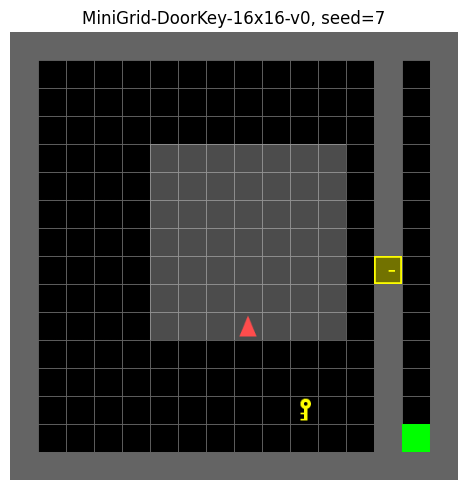

In [4]:
# Inspect and render one seeded MiniGrid instance.
env = make_env(render_mode="rgb_array")
obs, _ = reset_env(env, seed=SEED)
frame = render_env(env)

print("Environment:", ENV_ID)
print("Observation image shape:", obs_image(obs).shape)
print("Action space:", env.action_space)
print("Agent position:", get_agent_pos(env))
print("Agent direction:", int(env.unwrapped.agent_dir))
print("Mission:", obs.get("mission", "") if isinstance(obs, dict) else "")

fig = plt.figure(figsize=(5, 5))
plt.imshow(frame)
plt.axis("off")
plt.title(f"{ENV_ID}, seed={SEED}")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "environment_seed.png", dpi=160, bbox_inches="tight")
plt.show()
env.close()


Random-policy success rate: 0.0%
Random-policy average return: 0.000
Random-policy average episode length: 768.0


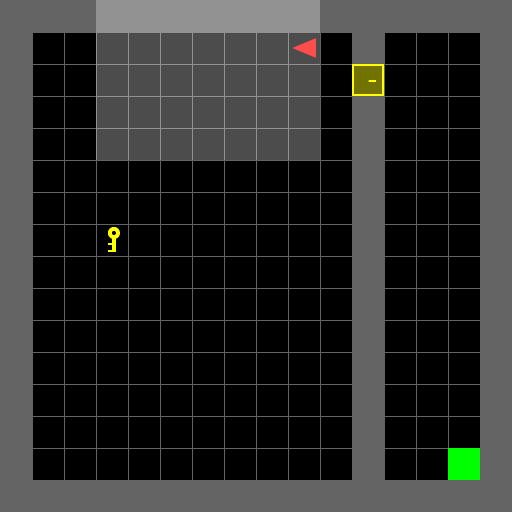

In [5]:
# Run and visualize a short random-policy baseline using only the five useful actions.
def make_random_policy(seed):
    rng = np.random.default_rng(int(seed))
    return lambda obs, env: int(rng.choice(USEFUL_ACTIONS))

random_eval = evaluate_policy(
    make_random_policy(SEED + 1),
    n_episodes=10,
    seed_start=100,
    record_positions=True,
)
print(f"Random-policy success rate: {100 * random_eval['success_rate']:.1f}%")
print(f"Random-policy average return: {random_eval['avg_return']:.3f}")
print(f"Random-policy average episode length: {random_eval['avg_length']:.1f}")

random_rollout = rollout_policy(
    make_random_policy(SEED + 2),
    seed=100,
    gif_path=OUTPUT_DIR / "random_policy.gif",
)
display_gif(random_rollout["gif_path"])


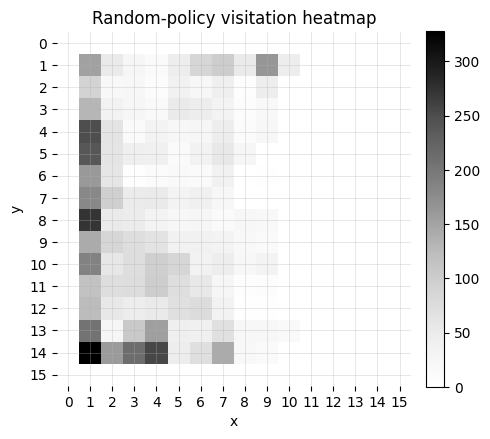

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))
plot_visit_heatmap(
    random_eval["positions"],
    ax=ax,
    title="Random-policy visitation heatmap",
    cmap="Greys",
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "random_policy_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

## 2. Generating expert demonstrations with a BFS oracle

We now build an expert planner from scratch. The oracle is allowed to use privileged full-state access to the grid layout. It plans over symbolic states:

- agent position `(x, y)`
- agent direction
- whether the key is currently carried
- whether the door is open or locked

The plan is still executed with valid low-level MiniGrid actions: turn left, turn right, move forward, pick up, and toggle the door.


In [6]:
LEFT, RIGHT, FORWARD, PICKUP, DROP, TOGGLE, DONE = range(7)
DIR_TO_VEC = {
    0: (1, 0),    # east
    1: (0, 1),    # south
    2: (-1, 0),   # west
    3: (0, -1),   # north
}
# Deterministic BFS action order. It prefers task-progress actions before rotations.
ORACLE_ACTIONS = [FORWARD, PICKUP, TOGGLE, LEFT, RIGHT]


@dataclass(frozen=True)
class DoorKeyLayout:
    width: int
    height: int
    walls: frozenset
    key_pos: tuple
    door_pos: tuple
    goal_pos: tuple


def build_layout(env):
    """Extract the fixed map information for the current episode."""
    grid = env.unwrapped.grid
    walls = set()
    key_pos, door_pos, goal_pos = None, None, None

    for x in range(int(grid.width)):
        for y in range(int(grid.height)):
            cell = grid.get(x, y)
            if cell is None:
                continue
            cell_type = getattr(cell, "type", None)
            if cell_type == "wall":
                walls.add((int(x), int(y)))
            elif cell_type == "key":
                key_pos = (int(x), int(y))
            elif cell_type == "door":
                door_pos = (int(x), int(y))
            elif cell_type == "goal":
                goal_pos = (int(x), int(y))

    if key_pos is None or door_pos is None or goal_pos is None:
        raise RuntimeError(
            f"Incomplete DoorKey map: key={key_pos}, door={door_pos}, goal={goal_pos}"
        )

    return DoorKeyLayout(
        width=int(grid.width),
        height=int(grid.height),
        walls=frozenset(walls),
        key_pos=key_pos,
        door_pos=door_pos,
        goal_pos=goal_pos,
    )


def symbolic_state_from_env(env, layout):
    """Encode z=(x,y,d,k,o,l) from the privileged environment state."""
    x, y = get_agent_pos(env)
    direction = int(env.unwrapped.agent_dir)
    carrying = env.unwrapped.carrying
    has_key = bool(carrying is not None and getattr(carrying, "type", None) == "key")

    door = env.unwrapped.grid.get(*layout.door_pos)
    if door is None or getattr(door, "type", None) != "door":
        raise RuntimeError("Door object not found at the fixed door position.")
    door_open = bool(door.is_open)
    door_locked = bool(door.is_locked)

    return (int(x), int(y), direction, has_key, door_open, door_locked)


# This is a helper function to compute the cell in front of a symbolic state.
def front_cell(state):
    x, y, direction, has_key, door_open, door_locked = state
    dx, dy = DIR_TO_VEC[int(direction)]
    return (x + dx, y + dy)


# This is a helper function to test whether a symbolic state can enter a grid cell.
def can_enter_cell(layout, pos, has_key, door_open):
    x, y = pos
    if x < 0 or x >= layout.width or y < 0 or y >= layout.height:
        return False
    if pos in layout.walls:
        return False
    if pos == layout.door_pos:
        return bool(door_open)
    # Before pickup, the key occupies its cell and cannot be walked through.
    if pos == layout.key_pos and not has_key:
        return False
    return True


def symbolic_transition(layout, state, action):
    """Exact deterministic dynamics for the five planner actions."""
    x, y, direction, has_key, door_open, door_locked = state
    action = int(action)

    if action == LEFT:
        direction = (int(direction) - 1) % 4

    elif action == RIGHT:
        direction = (int(direction) + 1) % 4

    elif action == FORWARD:
        nxt = front_cell(state)
        if can_enter_cell(layout, nxt, has_key, door_open):
            x, y = nxt

    elif action == PICKUP:
        # MiniGrid pickup changes the carried object but not the agent position.
        if (not has_key) and front_cell(state) == layout.key_pos:
            has_key = True

    elif action == TOGGLE:
        if front_cell(state) == layout.door_pos:
            if door_locked:
                if has_key:
                    # A matching key unlocks and opens the DoorKey door.
                    door_locked = False
                    door_open = True
            else:
                # An unlocked door toggles between open and closed.
                door_open = not door_open

    # Any invalid or unsupported action leaves the symbolic state unchanged.
    return (int(x), int(y), int(direction), bool(has_key), bool(door_open), bool(door_locked))


# This is a helper function to recover an action sequence from BFS parent pointers.
def reconstruct_plan(parent, action_taken, goal_state):
    actions = []
    state = goal_state
    while parent[state] is not None:
        actions.append(action_taken[state])
        state = parent[state]
    actions.reverse()
    return actions


def oracle_plan_from_state(layout, start_state):
    """Breadth-first search over the complete symbolic planning state."""
    start_state = tuple(start_state)
    if (start_state[0], start_state[1]) == layout.goal_pos:
        return []

    queue = deque([start_state])
    parent = {start_state: None}
    action_taken = {}

    while queue:
        state = queue.popleft()
        for action in ORACLE_ACTIONS:
            nxt = symbolic_transition(layout, state, action)
            if nxt == state or nxt in parent:
                continue
            parent[nxt] = state
            action_taken[nxt] = int(action)

            if (nxt[0], nxt[1]) == layout.goal_pos:
                return reconstruct_plan(parent, action_taken, nxt)
            queue.append(nxt)

    return None


# This is a helper function to query the expert action for the current environment state.
def oracle_action_from_env(env, layout):
    state = symbolic_state_from_env(env, layout)
    plan = oracle_plan_from_state(layout, state)
    if plan is None:
        raise RuntimeError(f"No oracle plan exists from state {state}.")
    if len(plan) == 0:
        return DONE
    return int(plan[0])


# This is a helper function to query the expert action for a stored symbolic state.
def oracle_action_from_symbolic_state(layout, state):
    plan = oracle_plan_from_state(layout, state)
    if plan is None:
        raise RuntimeError(f"No oracle plan exists from stored state {state}.")
    if len(plan) == 0:
        return DONE
    return int(plan[0])


def make_oracle_policy():
    """Build an oracle policy that caches the fixed map for each reset environment."""
    def policy(obs, env):
        base = env.unwrapped
        grid_id = id(base.grid)
        cached = getattr(base, "_imitation_oracle_layout_cache", None)
        if cached is None or cached[0] != grid_id:
            cached = (grid_id, build_layout(env))
            setattr(base, "_imitation_oracle_layout_cache", cached)
        layout = cached[1]

        action = oracle_action_from_env(env, layout)
        if action == DONE:
            # rollout_policy never asks for another action after a successful terminal step.
            raise RuntimeError("Oracle was queried in a terminal goal state.")
        return action

    return policy


In [7]:
# Smoke-test the symbolic dynamics and BFS oracle on controlled seeds.
SMOKE_TEST_EPISODES = 20
smoke_successes = []
smoke_lengths = []

for seed in tqdm(range(2000, 2000 + SMOKE_TEST_EPISODES), desc="oracle smoke test"):
    env = make_env(render_mode="rgb_array")
    obs, _ = reset_env(env, seed=seed)
    layout = build_layout(env)
    success = False
    steps = 0

    for step_idx in range(MAX_STEPS_PER_EPISODE):
        state_before = symbolic_state_from_env(env, layout)
        action = oracle_action_from_env(env, layout)
        assert action in USEFUL_ACTIONS, f"Oracle emitted disallowed action {action}."

        predicted_state = symbolic_transition(layout, state_before, action)
        obs, reward, terminated, truncated, _ = step_env_flags(env, action)
        actual_state = symbolic_state_from_env(env, layout)
        assert predicted_state == actual_state, (
            f"Symbolic/environment transition mismatch at seed={seed}, step={step_idx}:\n"
            f"state={state_before}, action={action}, predicted={predicted_state}, actual={actual_state}"
        )

        steps += 1
        if reward > 0.0 or get_agent_pos(env) == layout.goal_pos:
            success = True
        if terminated or truncated:
            break

    env.close()
    smoke_successes.append(success)
    smoke_lengths.append(steps)

print(f"Oracle smoke-test success: {sum(smoke_successes)}/{SMOKE_TEST_EPISODES}")
print(f"Oracle smoke-test average length: {np.mean(smoke_lengths):.1f}")
assert all(smoke_successes), "The BFS oracle must solve every smoke-test instance before dataset generation."


oracle smoke test:   0%|          | 0/20 [00:00<?, ?it/s]

Oracle smoke-test success: 20/20
Oracle smoke-test average length: 31.6


expert demonstrations:   0%|          | 0/1500 [00:00<?, ?it/s]

Expert transitions: 50204
Expert episodes: 1500
Expert success rate: 1.0
Expert average return: 0.961
Expert average length: 33.47
Terminations: 1500 Truncations: 0


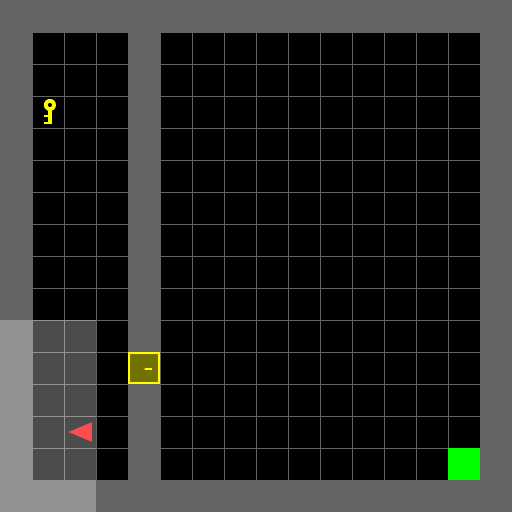

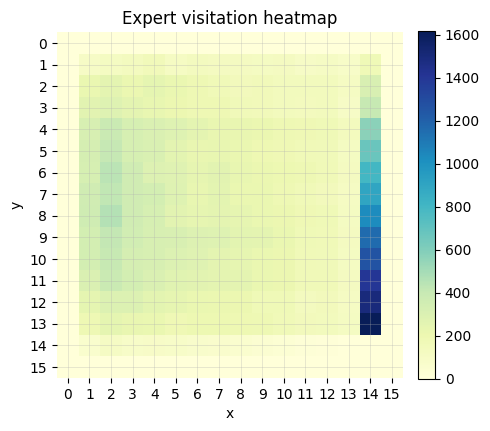

In [8]:
def generate_expert_dataset(n_episodes, seed_start=1000, max_steps=MAX_STEPS_PER_EPISODE):
    """Generate pre-action observations paired with freshly replanned BFS labels."""
    images = []
    actions = []
    positions = []
    symbolic_states = []
    rewards = []
    terminated_flags = []
    truncated_flags = []
    episode_ids = []
    step_ids = []

    episode_returns = []
    episode_lengths = []
    episode_successes = []
    episode_seeds = []

    for episode_id in tqdm(range(int(n_episodes)), desc="expert demonstrations"):
        seed = int(seed_start) + episode_id
        env = make_env(render_mode="rgb_array")
        obs, _ = reset_env(env, seed=seed)
        layout = build_layout(env)
        total_return = 0.0
        success = False
        length = 0

        for step_idx in range(int(max_steps)):
            # The sample is aligned with the state immediately before this expert action.
            pre_obs = obs_image(obs).copy()
            pre_pos = get_agent_pos(env)
            pre_state = symbolic_state_from_env(env, layout)
            action = oracle_action_from_env(env, layout)  # replan at every requested label
            if action not in USEFUL_ACTIONS:
                raise RuntimeError(f"Oracle emitted invalid training action {action}.")

            next_obs, reward, env_terminated, env_truncated, _ = step_env_flags(env, action)
            cutoff = (step_idx + 1 >= int(max_steps)) and not (env_terminated or env_truncated)
            terminated = bool(env_terminated)
            truncated = bool(env_truncated or cutoff)

            images.append(pre_obs)
            actions.append(int(action))
            positions.append(pre_pos)
            symbolic_states.append(pre_state)
            rewards.append(float(reward))
            terminated_flags.append(terminated)
            truncated_flags.append(truncated)
            episode_ids.append(int(episode_id))
            step_ids.append(int(step_idx))

            total_return += float(reward)
            length += 1
            success = bool(success or reward > 0.0 or get_agent_pos(env) == layout.goal_pos)
            obs = next_obs
            if terminated or truncated:
                break

        env.close()
        if not success:
            raise RuntimeError(f"BFS oracle failed on demonstration seed {seed}.")

        episode_returns.append(float(total_return))
        episode_lengths.append(int(length))
        episode_successes.append(bool(success))
        episode_seeds.append(seed)

    return {
        "obs": np.stack(images).astype(np.uint8),
        "actions": np.asarray(actions, dtype=np.int64),
        "positions": np.asarray(positions, dtype=np.int64),
        "symbolic_states": list(symbolic_states),
        "rewards": np.asarray(rewards, dtype=np.float32),
        "terminated": np.asarray(terminated_flags, dtype=bool),
        "truncated": np.asarray(truncated_flags, dtype=bool),
        "episode_ids": np.asarray(episode_ids, dtype=np.int64),
        "step_ids": np.asarray(step_ids, dtype=np.int64),
        "episode_returns": np.asarray(episode_returns, dtype=np.float32),
        "episode_lengths": np.asarray(episode_lengths, dtype=np.int64),
        "episode_successes": np.asarray(episode_successes, dtype=bool),
        "episode_seeds": np.asarray(episode_seeds, dtype=np.int64),
    }


# Create, summarize, and visualize the expert demonstration dataset.
expert_data = generate_expert_dataset(NUM_EXPERT_EPISODES, seed_start=1000)

print("Expert transitions:", len(expert_data["actions"]))
print("Expert episodes:", NUM_EXPERT_EPISODES)
print("Expert success rate:", expert_data["episode_successes"].mean())
print("Expert average return:", expert_data["episode_returns"].mean().round(3))
print("Expert average length:", expert_data["episode_lengths"].mean().round(2))
print("Terminations:", int(expert_data["terminated"].sum()),
      "Truncations:", int(expert_data["truncated"].sum()))

expert_gif = rollout_policy(
    make_oracle_policy(),
    seed=1000,
    gif_path=OUTPUT_DIR / "expert_oracle.gif",
)
display_gif(expert_gif["gif_path"])

fig, ax = plt.subplots(figsize=(5, 5))
plot_visit_heatmap(
    expert_data["positions"],
    ax=ax,
    title="Expert visitation heatmap",
    cmap="YlGnBu",
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "expert_visitation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()


## 3. Training a behavior cloning policy

Behavior cloning turns imitation learning into supervised learning. We train a policy to predict the expert action from the MiniGrid image observation.

$$
L_{BC}(\theta) = -\mathbb{E}_{(s,a)\sim D_E}\log \pi_\theta(a\mid s).
$$

We use a deliberately small CNN. The observation is symbolic rather than photographic, so a compact model is enough for this project.


In [9]:
# MiniGrid's three semantic channels have standard maxima 10, 5, and 2:
# object index, color index, and door state respectively.
OBS_NORMALIZER = torch.tensor([10.0, 5.0, 2.0], dtype=torch.float32).view(3, 1, 1)
N_ACTIONS = len(USEFUL_ACTIONS)
ACTION_TO_CLASS = {action: idx for idx, action in enumerate(USEFUL_ACTIONS)}
CLASS_TO_ACTION = np.asarray(USEFUL_ACTIONS, dtype=np.int64)


# This is a helper function to preprocess one MiniGrid image for the model.
def preprocess_image(image):
    x = torch.as_tensor(image, dtype=torch.float32)
    if x.ndim != 3:
        raise ValueError(f"Expected image with 3 dimensions, got shape {tuple(x.shape)}")
    if x.shape[-1] == 3:
        x = x.permute(2, 0, 1)
    if x.shape[0] != 3:
        raise ValueError(f"Expected 3 semantic channels, got shape {tuple(x.shape)}")
    return x / OBS_NORMALIZER


# This is a helper function to turn an observation into a model input batch.
def obs_to_tensor(obs, device=DEVICE):
    x = preprocess_image(obs_image(obs)).unsqueeze(0)
    return x.to(device)


class ImageActionDataset(Dataset):
    def __init__(self, images, actions, indices=None):
        self.images = np.asarray(images, dtype=np.uint8)
        self.actions = np.asarray(actions, dtype=np.int64)
        if len(self.images) != len(self.actions):
            raise ValueError("images and actions must have the same length")
        self.indices = np.arange(len(self.actions)) if indices is None else np.asarray(indices, dtype=np.int64)

        unsupported = sorted(set(map(int, self.actions[self.indices])) - set(USEFUL_ACTIONS))
        if unsupported:
            raise ValueError(f"Dataset contains actions outside the allowed DoorKey set: {unsupported}")

    def __len__(self):
        return int(len(self.indices))

    def __getitem__(self, idx):
        source_idx = int(self.indices[idx])
        image = preprocess_image(self.images[source_idx])
        action_id = int(self.actions[source_idx])
        action_class = ACTION_TO_CLASS[action_id]
        return image, torch.tensor(action_class, dtype=torch.long)


def make_data_loaders(images, actions, val_fraction=VAL_FRACTION,
                      batch_size=BATCH_SIZE, seed=SEED):
    """Create a reproducible transition-level train/validation split."""
    n = len(actions)
    if n < 2:
        raise ValueError("Need at least two labeled examples for training/validation.")

    rng = np.random.default_rng(int(seed))
    indices = rng.permutation(n)
    n_val = int(round(float(val_fraction) * n))
    n_val = min(max(n_val, 1), n - 1)
    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    train_ds = ImageActionDataset(images, actions, train_idx)
    val_ds = ImageActionDataset(images, actions, val_idx)

    generator = torch.Generator()
    generator.manual_seed(int(seed))
    train_loader = DataLoader(
        train_ds,
        batch_size=int(batch_size),
        shuffle=True,
        generator=generator,
        num_workers=0,
        drop_last=False,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=int(batch_size),
        shuffle=False,
        num_workers=0,
        drop_last=False,
    )
    return train_loader, val_loader


class SmallMinigridPolicy(nn.Module):
    def __init__(self, n_actions=N_ACTIONS):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((3, 3)),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 3 * 3, 128),
            nn.ReLU(),
            nn.Linear(128, int(n_actions)),
        )

    def forward(self, x):
        return self.head(self.encoder(x))


def _evaluate_classifier(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits, y, reduction="sum")
            total_loss += float(loss.item())
            total_correct += int((logits.argmax(dim=1) == y).sum().item())
            total_count += int(y.numel())
    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)


def train_policy(model, train_loader, val_loader=None, epochs=5, lr=1e-3,
                 device=DEVICE, desc="training", optimizer=None):
    """Train with CE + gradient clipping and restore the best validation checkpoint."""
    model.to(device)
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=float(lr))
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    best_val_acc = -float("inf")
    best_epoch = 0

    for epoch in tqdm(range(1, int(epochs) + 1), desc=desc):
        model.train()
        running_loss = 0.0
        count = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += float(loss.item()) * int(y.numel())
            count += int(y.numel())

        train_loss = running_loss / max(count, 1)
        history["train_loss"].append(train_loss)

        if val_loader is not None:
            val_loss, val_acc = _evaluate_classifier(model, val_loader, device)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)

            # Fixed validation criterion: higher accuracy, then lower CE loss.
            is_better = (val_acc > best_val_acc + 1e-12) or (
                abs(val_acc - best_val_acc) <= 1e-12 and val_loss < best_val_loss
            )
            if is_better:
                best_val_acc = float(val_acc)
                best_val_loss = float(val_loss)
                best_epoch = int(epoch)
                best_state = copy.deepcopy(model.state_dict())
        else:
            # If no validation loader is supplied, keep the latest model.
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = int(epoch)

    model.load_state_dict(best_state)
    if val_loader is not None:
        restored_val_loss, restored_val_acc = _evaluate_classifier(model, val_loader, device)
    else:
        restored_val_loss, restored_val_acc = float("nan"), float("nan")

    history["best_epoch"] = best_epoch
    history["best_val_loss"] = restored_val_loss
    history["best_val_acc"] = restored_val_acc
    return history


@torch.no_grad()
def model_action(model, obs, deterministic=True, temperature=1.0):
    """Select only among the five useful DoorKey actions."""
    model.eval()
    logits = model(obs_to_tensor(obs, device=DEVICE)).squeeze(0)
    if deterministic:
        action_class = int(torch.argmax(logits).item())
    else:
        temperature = max(float(temperature), 1e-6)
        probs = torch.softmax(logits / temperature, dim=-1)
        action_class = int(torch.multinomial(probs, num_samples=1).item())
    action = int(CLASS_TO_ACTION[action_class])
    assert action in USEFUL_ACTIONS
    return action


@torch.no_grad()
def model_entropy(model, obs):
    """Entropy after restricting/renormalizing over the useful action set.

    The network emits exactly those five logits, so softmax is already the required
    restricted-and-renormalized distribution.
    """
    model.eval()
    logits = model(obs_to_tensor(obs, device=DEVICE)).squeeze(0)
    log_probs = F.log_softmax(logits, dim=-1)
    probs = log_probs.exp()
    return float((-(probs * log_probs).sum()).item())


BC:   0%|          | 0/20 [00:00<?, ?it/s]

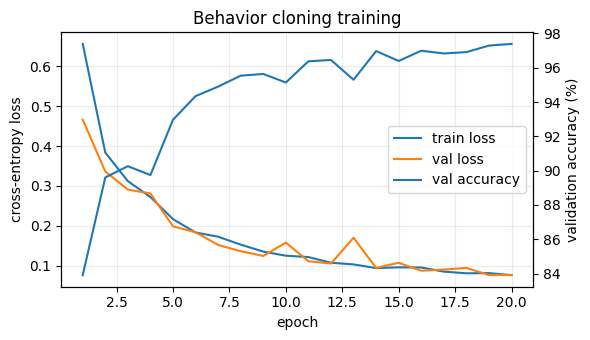

Best/restored validation accuracy: 97.4% (epoch 20)
BC closed-loop success rate: 94.0%
BC average return: 0.899
BC average episode length: 81.4
Supervised validation accuracy and closed-loop task metrics are reported separately.


In [10]:
train_loader, val_loader = make_data_loaders(
    expert_data["obs"],
    expert_data["actions"],
    seed=SEED,
)

bc_model = SmallMinigridPolicy().to(DEVICE)
bc_history = train_policy(
    bc_model,
    train_loader,
    val_loader,
    epochs=BC_EPOCHS,
    lr=BC_LR,
    desc="BC",
)

plot_training_curves(
    bc_history,
    title="Behavior cloning training",
    save_path=OUTPUT_DIR / "bc_training_curves.png",
)

bc_policy_fn = lambda obs, env: model_action(bc_model, obs, deterministic=True)
bc_eval = evaluate_policy(
    bc_policy_fn,
    n_episodes=EVAL_EPISODES,
    seed_start=EVAL_SEED_START,
    record_positions=True,
)

print(f"Best/restored validation accuracy: {bc_history['best_val_acc'] * 100:.1f}% "
      f"(epoch {bc_history['best_epoch']})")
print(f"BC closed-loop success rate: {bc_eval['success_rate'] * 100:.1f}%")
print(f"BC average return: {bc_eval['avg_return']:.3f}")
print(f"BC average episode length: {bc_eval['avg_length']:.1f}")
print("Supervised validation accuracy and closed-loop task metrics are reported separately.")


## 4. Rolling out BC and showing where it fails

The learner now acts in the real environment. We search over seeds for a BC failure case and display the first failure found.

The main failure mode is distribution mismatch: small supervised errors can move the learner into states that were rare or absent in the expert demonstrations. Once there, the policy has less useful training signal.


BC failure found automatically at seed 4011.
{'return': 0.0, 'success': False, 'length': 768, 'terminated': False, 'truncated': True}


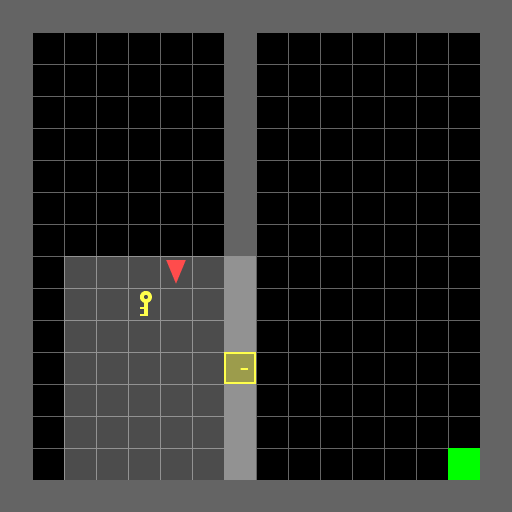

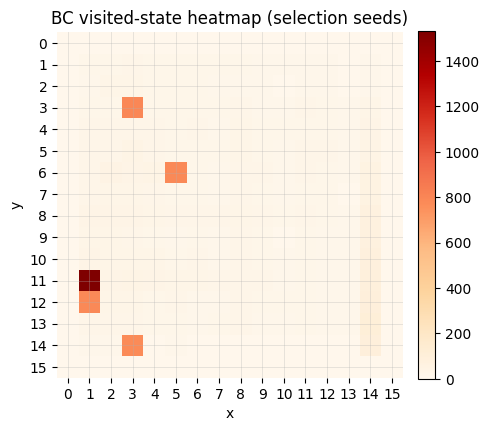

In [11]:
def find_seed_for_outcome(policy_fn, target_success, seed_start=4000, n_search=500):
    """Return the first seed whose rollout has the requested outcome."""
    target_success = bool(target_success)
    for seed in range(int(seed_start), int(seed_start) + int(n_search)):
        result = rollout_policy(policy_fn, seed=seed)
        if bool(result["success"]) == target_success:
            return int(seed)
    return None


# Automatically locate and visualize a behavior-cloning failure trajectory.
bc_policy_fn = lambda obs, env: model_action(bc_model, obs, deterministic=True)
bc_failure_seed = find_seed_for_outcome(
    bc_policy_fn,
    target_success=False,
    seed_start=4000,
    n_search=500,
)

if bc_failure_seed is None:
    raise RuntimeError(
        "No BC failure was found in 500 controlled seeds. "
        "For the required failure analysis, increase the search range or reduce the initial demonstration budget."
    )

print(f"BC failure found automatically at seed {bc_failure_seed}.")
bc_rollout = rollout_policy(
    bc_policy_fn,
    seed=bc_failure_seed,
    gif_path=OUTPUT_DIR / "bc_failure.gif",
)
print({
    "return": round(bc_rollout["return"], 3),
    "success": bc_rollout["success"],
    "length": bc_rollout["length"],
    "terminated": bc_rollout["terminated"],
    "truncated": bc_rollout["truncated"],
})
display_gif(bc_rollout["gif_path"])

fig, ax = plt.subplots(figsize=(5, 5))
plot_visit_heatmap(
    bc_eval["positions"],
    ax=ax,
    title="BC visited-state heatmap (selection seeds)",
    cmap="OrRd",
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "bc_visitation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()


## 5. Implementing DAgger

DAgger fixes the dataset mismatch by asking the expert to label states visited by the learner:

$$
D \leftarrow D \cup \{(s, \pi_E(s)) : s \text{ visited by } \pi_\theta\}.
$$

Then we continue training the policy on the aggregated dataset. We track both success rate and the number of expert labels used.


DAgger 1/8:   0%|          | 0/5 [00:00<?, ?it/s]

DAgger iter 1: +402 labels, total=50606, success=95.0%, return=0.908, length=74.7


DAgger 2/8:   0%|          | 0/5 [00:00<?, ?it/s]

DAgger iter 2: +330 labels, total=50936, success=94.0%, return=0.896, length=83.4


DAgger 3/8:   0%|          | 0/5 [00:00<?, ?it/s]

...

DAgger iter 6: +1074 labels, total=53141, success=96.0%, return=0.918, length=66.2


DAgger 7/8:   0%|          | 0/5 [00:00<?, ?it/s]

DAgger iter 7: +1046 labels, total=54187, success=86.0%, return=0.820, length=141.7


DAgger 8/8:   0%|          | 0/5 [00:00<?, ?it/s]

DAgger iter 8: +1103 labels, total=55290, success=96.0%, return=0.917, length=67.6

Full DAgger label accounting
Initial BC labels: 50204
Additional DAgger labels queried: 5086
Total labels queried: 55290
Best checkpoint iteration: 3
Labels available at best checkpoint: 51348
Checkpoint criterion: success rate, then return, then shorter episode length.


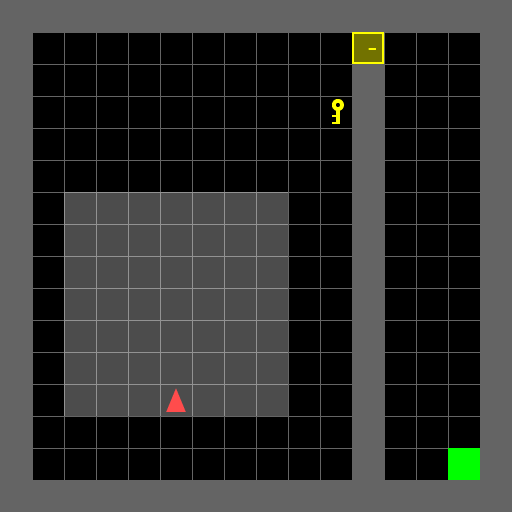

In [12]:
def collect_dagger_labels(model, n_rollouts, seed_start, max_steps=MAX_STEPS_PER_EPISODE,
                          stochastic_rollout=False):
    """Query the oracle at every learner-visited state occurrence, repeats included."""
    images = []
    actions = []
    positions = []
    symbolic_states = []
    episode_seeds = []
    step_ids = []

    for rollout_idx in range(int(n_rollouts)):
        seed = int(seed_start) + rollout_idx
        env = make_env(render_mode="rgb_array")
        obs, _ = reset_env(env, seed=seed)
        layout = build_layout(env)

        stagnation_counter = 0
        last_pos = None

        for step_idx in range(int(max_steps)):
            # Query the expert on the exact pre-action state visited by the learner.
            images.append(obs_image(obs).copy())
            positions.append(get_agent_pos(env))
            state = symbolic_state_from_env(env, layout)
            symbolic_states.append(state)
            expert_action = oracle_action_from_env(env, layout)
            if expert_action not in USEFUL_ACTIONS:
                raise RuntimeError(f"Unexpected oracle action {expert_action} during DAgger.")
            actions.append(int(expert_action))
            episode_seeds.append(seed)
            step_ids.append(step_idx)

            learner_action = model_action(
                model,
                obs,
                deterministic=not stochastic_rollout,
            )
            obs, _, terminated, truncated, _ = step_env_flags(env, learner_action)
            if terminated or truncated:
                break

        env.close()

    return {
        "obs": np.stack(images).astype(np.uint8) if images else np.empty((0, AGENT_VIEW_SIZE, AGENT_VIEW_SIZE, 3), dtype=np.uint8),
        "actions": np.asarray(actions, dtype=np.int64),
        "positions": np.asarray(positions, dtype=np.int64).reshape(-1, 2),
        "symbolic_states": symbolic_states,
        "episode_seeds": np.asarray(episode_seeds, dtype=np.int64),
        "step_ids": np.asarray(step_ids, dtype=np.int64),
    }


# Full DAgger starts from exactly the trained BC checkpoint.
dagger_model = copy.deepcopy(bc_model).to(DEVICE)
dagger_images = [img.copy() for img in expert_data["obs"]]
dagger_actions = [int(a) for a in expert_data["actions"]]
initial_expert_labels = int(len(dagger_actions))
dagger_additional_labels = 0

# Row 0 is BC evaluated on the same selection budget/seeds as every later iterate.
dagger_history = [{
    "iteration": 0,
    "labels": initial_expert_labels,
    "initial_labels": initial_expert_labels,
    "additional_labels": 0,
    "new_labels": 0,
    "success_rate": bc_eval["success_rate"],
    "avg_return": bc_eval["avg_return"],
    "avg_length": bc_eval["avg_length"],
}]

dagger_best_model = copy.deepcopy(dagger_model)
dagger_best_eval = dict(bc_eval)
dagger_best_iteration = 0
dagger_best_labels = initial_expert_labels
# Keep optimizer state across DAgger iterations for stable warm-start training.
dag_optimizer = torch.optim.Adam(dagger_model.parameters(), lr=float(DAGGER_LR))

for iteration in range(1, DAGGER_ITERS + 1):
    rollout_seed_start = 5000 + (iteration - 1) * DAGGER_ROLLOUTS_PER_ITER
    new_data = collect_dagger_labels(
        dagger_model,
        n_rollouts=DAGGER_ROLLOUTS_PER_ITER,
        seed_start=rollout_seed_start,
        stochastic_rollout=False,
    )

    dagger_images.extend([img.copy() for img in new_data["obs"]])
    dagger_actions.extend([int(a) for a in new_data["actions"]])
    new_label_count = int(len(new_data["actions"]))
    dagger_additional_labels += new_label_count
    total_labels = initial_expert_labels + dagger_additional_labels

    train_loader, val_loader = make_data_loaders(
        np.stack(dagger_images),
        np.asarray(dagger_actions, dtype=np.int64),
        seed=SEED + 100 + iteration,
    )
    train_policy(
        dagger_model,
        train_loader,
        val_loader,
        epochs=DAGGER_EPOCHS_PER_ITER,
        lr=DAGGER_LR,
        desc=f"DAgger {iteration}/{DAGGER_ITERS}",
        optimizer=dag_optimizer,
    )

    current_eval = evaluate_policy(
        lambda obs, env: model_action(dagger_model, obs, deterministic=True),
        n_episodes=EVAL_EPISODES,
        seed_start=EVAL_SEED_START,
        record_positions=False,
    )
    row = {
        "iteration": iteration,
        "labels": total_labels,
        "initial_labels": initial_expert_labels,
        "additional_labels": dagger_additional_labels,
        "new_labels": new_label_count,
        "success_rate": current_eval["success_rate"],
        "avg_return": current_eval["avg_return"],
        "avg_length": current_eval["avg_length"],
    }
    dagger_history.append(row)

    if checkpoint_score(current_eval) > checkpoint_score(dagger_best_eval):
        dagger_best_eval = dict(current_eval)
        dagger_best_model = copy.deepcopy(dagger_model)
        dagger_best_iteration = iteration
        dagger_best_labels = total_labels

    print(
        f"DAgger iter {iteration}: +{new_label_count} labels, total={total_labels}, "
        f"success={100 * current_eval['success_rate']:.1f}%, "
        f"return={current_eval['avg_return']:.3f}, length={current_eval['avg_length']:.1f}"
    )

print("\nFull DAgger label accounting")
print("Initial BC labels:", initial_expert_labels)
print("Additional DAgger labels queried:", dagger_additional_labels)
print("Total labels queried:", initial_expert_labels + dagger_additional_labels)
print("Best checkpoint iteration:", dagger_best_iteration)
print("Labels available at best checkpoint:", dagger_best_labels)
print("Checkpoint criterion: success rate, then return, then shorter episode length.")

dagger_best_policy_fn = lambda obs, env: model_action(dagger_best_model, obs, deterministic=True)
dag_success_seed = find_seed_for_outcome(
    dagger_best_policy_fn, target_success=True, seed_start=7000, n_search=200
)
if dag_success_seed is None:
    dag_success_seed = 7000

dagger_gif = rollout_policy(
    dagger_best_policy_fn,
    seed=dag_success_seed,
    gif_path=OUTPUT_DIR / "dagger_best_representative.gif",
)
display_gif(dagger_gif["gif_path"])


## 6. Budgeted critical-state DAgger

Full DAgger can spend many labels. Here we roll out the learner, score visited states by policy entropy, and query the expert only on the top-k most uncertain states:

$$
H(\pi(\cdot\mid s)) = -\sum_a \pi(a\mid s)\log \pi(a\mid s).
$$

This is a simple active-learning version of DAgger: label the states where the policy is least sure.


Critical-state deduplication: fixed-map signature + complete symbolic state z.
Scope: within current iteration only. Tie-break: first encounter order.


Critical DAgger 1/8:   0%|          | 0/5 [00:00<?, ?it/s]

Critical iter 1: candidates=2939, unique=1449, queried=1200, total=51404, success=94.0%, return=0.896, length=83.3


Critical DAgger 2/8:   0%|          | 0/5 [00:00<?, ?it/s]

Critical iter 2: candidates=4327, unique=1285, queried=1200, total=52604, success=97.0%, return=0.926, length=60.7


...

Critical iter 6: candidates=4487, unique=1438, queried=1200, total=57404, success=95.0%, return=0.909, length=73.7


Critical DAgger 7/8:   0%|          | 0/5 [00:00<?, ?it/s]

Critical iter 7: candidates=3031, unique=1501, queried=1200, total=58604, success=96.0%, return=0.918, length=66.2


Critical DAgger 8/8:   0%|          | 0/5 [00:00<?, ?it/s]

Critical iter 8: candidates=2239, unique=1398, queried=1200, total=59804, success=95.0%, return=0.909, length=73.4

Critical-state DAgger label accounting
Initial BC labels: 50204
Additional critical-state labels queried: 9600
Total labels queried: 59804
Best checkpoint iteration: 2
Labels available at best checkpoint: 52604
Checkpoint criterion: success rate, then return, then shorter episode length.


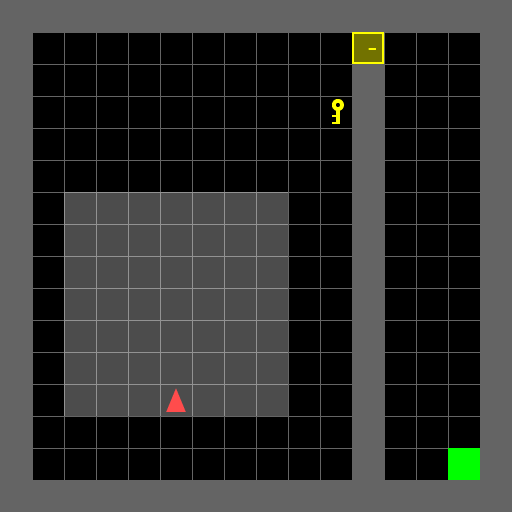

In [13]:
def collect_uncertain_candidates(model, n_rollouts, seed_start, max_steps=MAX_STEPS_PER_EPISODE,
                                 stochastic_rollout=False):
    """Collect learner-visited pre-action states and their current policy entropy."""
    candidates = []
    encounter_index = 0

    for rollout_idx in range(int(n_rollouts)):
        seed = int(seed_start) + rollout_idx
        env = make_env(render_mode="rgb_array")
        obs, _ = reset_env(env, seed=seed)
        layout = build_layout(env)

        stagnation_counter = 0
        last_pos = None

        for step_idx in range(int(max_steps)):
            candidates.append({
                "obs": obs_image(obs).copy(),
                "position": get_agent_pos(env),
                "state": symbolic_state_from_env(env, layout),
                "layout": layout,
                "entropy": float(model_entropy(model, obs)),
                "seed": seed,
                "step": step_idx,
                "encounter_index": encounter_index,
            })
            encounter_index += 1

            learner_action = model_action(
                model,
                obs,
                deterministic=not stochastic_rollout,
            )
            obs, _, terminated, truncated, _ = step_env_flags(env, learner_action)
            if terminated or truncated:
                break

        env.close()

    return candidates


def _layout_signature(layout):
    return (
        int(layout.width),
        int(layout.height),
        tuple(sorted(layout.walls)),
        tuple(layout.key_pos),
        tuple(layout.door_pos),
        tuple(layout.goal_pos),
    )


def label_top_uncertain_states(candidates, k):
    """Deduplicate by complete planning state, then label deterministic top-k entropy states."""
    # Within-iteration deduplication only. The first occurrence is retained.
    unique = {}
    for candidate in candidates:
        key = (_layout_signature(candidate["layout"]), tuple(candidate["state"]))
        if key not in unique:
            unique[key] = candidate

    ranked = sorted(
        unique.values(),
        key=lambda c: (-float(c["entropy"]), int(c["encounter_index"])),
    )
    selected = ranked[:min(int(k), len(ranked))]

    images = []
    actions = []
    positions = []
    entropies = []
    symbolic_states = []

    for candidate in selected:
        expert_action = oracle_action_from_symbolic_state(
            candidate["layout"], candidate["state"]
        )
        if expert_action not in USEFUL_ACTIONS:
            raise RuntimeError(f"Unexpected oracle action {expert_action} in critical-state DAgger.")
        images.append(candidate["obs"].copy())
        actions.append(int(expert_action))
        positions.append(candidate["position"])
        entropies.append(float(candidate["entropy"]))
        symbolic_states.append(candidate["state"])

    return {
        "obs": np.stack(images).astype(np.uint8) if images else np.empty((0, AGENT_VIEW_SIZE, AGENT_VIEW_SIZE, 3), dtype=np.uint8),
        "actions": np.asarray(actions, dtype=np.int64),
        "positions": np.asarray(positions, dtype=np.int64).reshape(-1, 2),
        "entropies": np.asarray(entropies, dtype=np.float32),
        "symbolic_states": symbolic_states,
        "num_candidates": int(len(candidates)),
        "num_unique": int(len(unique)),
        "num_selected": int(len(selected)),
    }


# Critical-state DAgger starts from the identical BC checkpoint and initial dataset.
critical_model = copy.deepcopy(bc_model).to(DEVICE)
critical_images = [img.copy() for img in expert_data["obs"]]
critical_actions = [int(a) for a in expert_data["actions"]]
critical_additional_labels = 0

critical_history = [{
    "iteration": 0,
    "labels": initial_expert_labels,
    "initial_labels": initial_expert_labels,
    "additional_labels": 0,
    "new_labels": 0,
    "candidates": 0,
    "unique_candidates": 0,
    "success_rate": bc_eval["success_rate"],
    "avg_return": bc_eval["avg_return"],
    "avg_length": bc_eval["avg_length"],
}]

critical_best_model = copy.deepcopy(critical_model)
critical_best_eval = dict(bc_eval)
critical_best_iteration = 0
critical_best_labels = initial_expert_labels
# Keep optimizer state across critical-state DAgger iterations.
critical_optimizer = torch.optim.Adam(critical_model.parameters(), lr=float(CRITICAL_LR))

print("Critical-state deduplication: fixed-map signature + complete symbolic state z.")
print("Scope: within current iteration only. Tie-break: first encounter order.")

for iteration in range(1, CRITICAL_ITERS + 1):
    rollout_seed_start = 5000 + (iteration - 1) * CRITICAL_ROLLOUTS_PER_ITER
    candidates = collect_uncertain_candidates(
        critical_model,
        n_rollouts=CRITICAL_ROLLOUTS_PER_ITER,
        seed_start=rollout_seed_start,
        stochastic_rollout=False,
    )
    labeled = label_top_uncertain_states(candidates, CRITICAL_LABELS_PER_ITER)

    critical_images.extend([img.copy() for img in labeled["obs"]])
    critical_actions.extend([int(a) for a in labeled["actions"]])
    new_label_count = int(labeled["num_selected"])
    critical_additional_labels += new_label_count
    total_labels = initial_expert_labels + critical_additional_labels

    train_loader, val_loader = make_data_loaders(
        np.stack(critical_images),
        np.asarray(critical_actions, dtype=np.int64),
        seed=SEED + 200 + iteration,
    )
    train_policy(
        critical_model,
        train_loader,
        val_loader,
        epochs=CRITICAL_EPOCHS_PER_ITER,
        lr=CRITICAL_LR,
        desc=f"Critical DAgger {iteration}/{CRITICAL_ITERS}",
        optimizer=critical_optimizer,
    )

    current_eval = evaluate_policy(
        lambda obs, env: model_action(critical_model, obs, deterministic=True),
        n_episodes=EVAL_EPISODES,
        seed_start=EVAL_SEED_START,
        record_positions=False,
    )
    row = {
        "iteration": iteration,
        "labels": total_labels,
        "initial_labels": initial_expert_labels,
        "additional_labels": critical_additional_labels,
        "new_labels": new_label_count,
        "candidates": labeled["num_candidates"],
        "unique_candidates": labeled["num_unique"],
        "success_rate": current_eval["success_rate"],
        "avg_return": current_eval["avg_return"],
        "avg_length": current_eval["avg_length"],
    }
    critical_history.append(row)

    if checkpoint_score(current_eval) > checkpoint_score(critical_best_eval):
        critical_best_eval = dict(current_eval)
        critical_best_model = copy.deepcopy(critical_model)
        critical_best_iteration = iteration
        critical_best_labels = total_labels

    print(
        f"Critical iter {iteration}: candidates={labeled['num_candidates']}, "
        f"unique={labeled['num_unique']}, queried={new_label_count}, total={total_labels}, "
        f"success={100 * current_eval['success_rate']:.1f}%, "
        f"return={current_eval['avg_return']:.3f}, length={current_eval['avg_length']:.1f}"
    )

print("\nCritical-state DAgger label accounting")
print("Initial BC labels:", initial_expert_labels)
print("Additional critical-state labels queried:", critical_additional_labels)
print("Total labels queried:", initial_expert_labels + critical_additional_labels)
print("Best checkpoint iteration:", critical_best_iteration)
print("Labels available at best checkpoint:", critical_best_labels)
print("Checkpoint criterion: success rate, then return, then shorter episode length.")

critical_best_policy_fn = lambda obs, env: model_action(critical_best_model, obs, deterministic=True)
critical_success_seed = find_seed_for_outcome(
    critical_best_policy_fn, target_success=True, seed_start=7000, n_search=200
)
if critical_success_seed is None:
    critical_success_seed = 7000

critical_gif = rollout_policy(
    critical_best_policy_fn,
    seed=critical_success_seed,
    gif_path=OUTPUT_DIR / "critical_dagger_best_representative.gif",
)
display_gif(critical_gif["gif_path"])


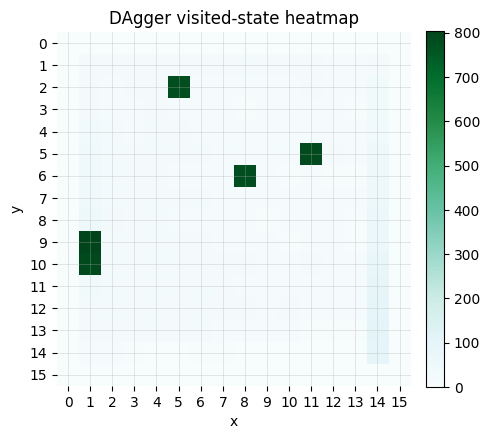

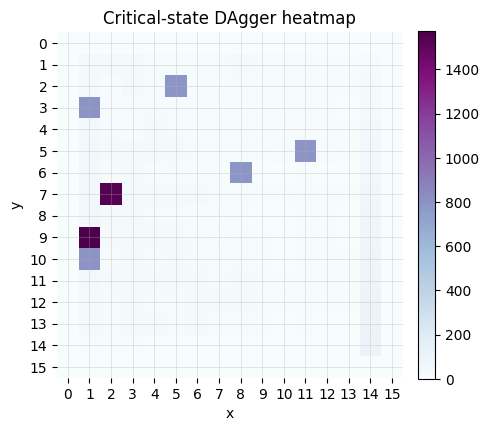

In [20]:
# Separate final visitation heatmaps for the best DAgger checkpoints

# Full DAgger heatmap
fig, ax = plt.subplots(figsize=(5, 5))

plot_visit_heatmap(
    final_dagger_eval["positions"],
    ax=ax,
    title="DAgger visited-state heatmap",
    cmap="BuGn"
)

plt.tight_layout()
fig.savefig(
    OUTPUT_DIR / "dagger_visited_state_heatmap.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()


# Critical-state DAgger heatmap
fig, ax = plt.subplots(figsize=(5, 5))

plot_visit_heatmap(
    final_critical_eval["positions"],
    ax=ax,
    title="Critical-state DAgger heatmap",
    cmap="BuPu"
)

plt.tight_layout()
fig.savefig(
    OUTPUT_DIR / "critical_dagger_visited_state_heatmap.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

## 7. Final comparison and visual summary

We finish with label efficiency, held-out final evaluation, final heatmaps, and a compact metrics table. The success-versus-label curves plot the **current iterate** on the fixed selection seeds. The final table and heatmaps use the **best checkpoint** selected by the same criterion for both DAgger variants, and all three methods are then re-evaluated on the same separate held-out seed block.

The final table reports the initial BC label count and the additional labels associated with each selected checkpoint. We also print the total labels actually queried over the complete DAgger runs so label accounting remains transparent.


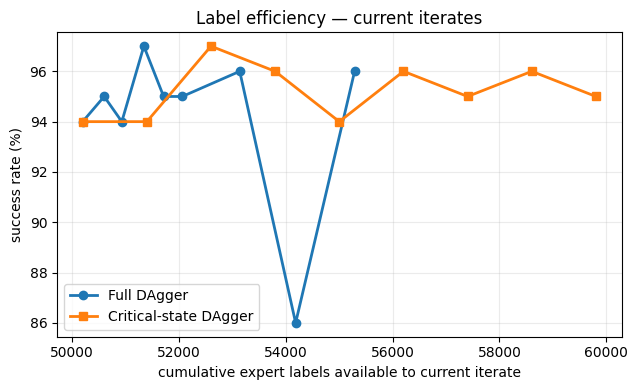

### Held-out final metrics — best checkpoints

| method | initial labels | additional labels | total labels at checkpoint | success rate | return (mean ± sd) | length (mean ± sd) |
|---|---:|---:|---:|---:|---:|---:|
| BC | 50204 | 0 | 50204 | 96.0% | 0.917 ± 0.189 | 67.5 ± 144.2 |
| Full DAgger (best iter 3) | 50204 | 1144 | 51348 | 95.0% | 0.909 ± 0.210 | 73.3 ± 160.5 |
| Critical DAgger (best iter 2) | 50204 | 2400 | 52604 | 91.0% | 0.869 ± 0.275 | 104.1 ± 210.1 |

Matched final evaluation: 100 episodes, seeds 9000..9099, horizon 768
Full DAgger total labels actually queried during the complete run: 55290
Critical-state DAgger total labels actually queried during the complete run: 59804


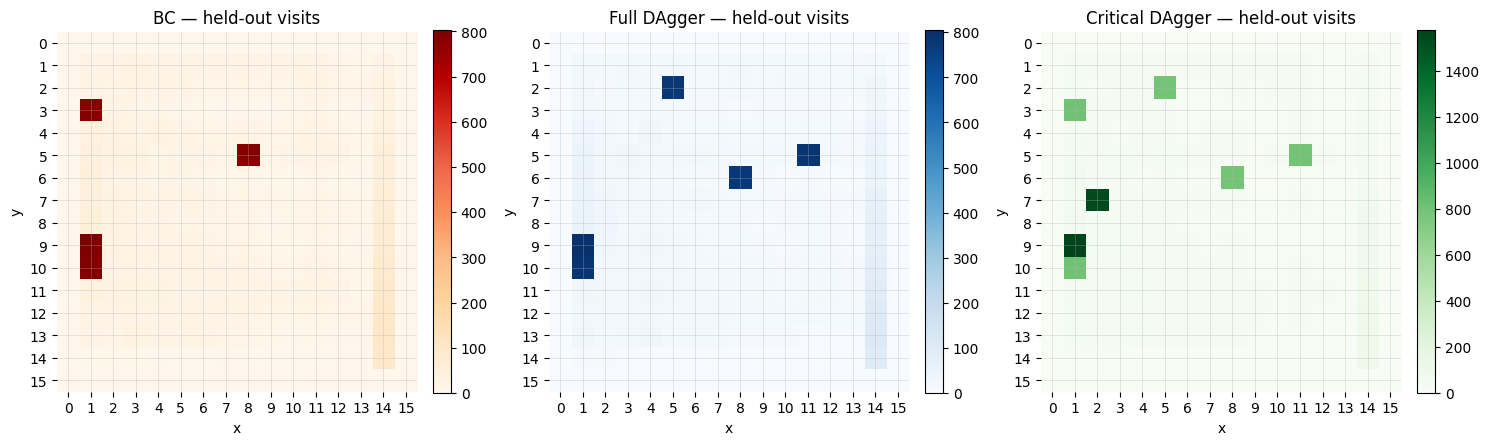

Saved summary: outputs/experiment_summary.json


In [14]:
# This is a helper function to plot success rate versus expert-label count.
def plot_label_efficiency(curves, save_path=None):
    fig = plt.figure(figsize=(6.5, 4))
    for name, history, marker in curves:
        labels = [row["labels"] for row in history]
        success = [100.0 * row["success_rate"] for row in history]
        plt.plot(labels, success, marker=marker, linewidth=2, label=name)
    plt.xlabel("cumulative expert labels available to current iterate")
    plt.ylabel("success rate (%)")
    plt.title("Label efficiency — current iterates")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


# This is a helper function to display a compact Markdown results table.
def display_results_table(rows):
    lines = [
        "| method | initial labels | additional labels | total labels at checkpoint | success rate | return (mean ± sd) | length (mean ± sd) |",
        "|---|---:|---:|---:|---:|---:|---:|",
    ]
    for row in rows:
        lines.append(
            f"| {row['method']} | {row['initial_labels']} | {row['additional_labels']} | "
            f"{row['labels']} | {row['success_rate'] * 100:.1f}% | "
            f"{row['avg_return']:.3f} ± {row['std_return']:.3f} | "
            f"{row['avg_length']:.1f} ± {row['std_length']:.1f} |"
        )
    display(Markdown("\n".join(lines)))


# 1) Current-iterate success versus cumulative expert labels.
plot_label_efficiency(
    [
        ("Full DAgger", dagger_history, "o"),
        ("Critical-state DAgger", critical_history, "s"),
    ],
    save_path=OUTPUT_DIR / "success_vs_expert_labels.png",
)

# 2) Held-out final evaluation: exactly the same episodes, seeds, and horizon for all methods.
final_bc_eval = evaluate_policy(
    bc_policy_fn,
    n_episodes=EVAL_EPISODES,
    seed_start=FINAL_EVAL_SEED_START,
    record_positions=True,
)
final_dagger_eval = evaluate_policy(
    dagger_best_policy_fn,
    n_episodes=EVAL_EPISODES,
    seed_start=FINAL_EVAL_SEED_START,
    record_positions=True,
)
final_critical_eval = evaluate_policy(
    critical_best_policy_fn,
    n_episodes=EVAL_EPISODES,
    seed_start=FINAL_EVAL_SEED_START,
    record_positions=True,
)

comparison_rows = [
    {
        "method": "BC",
        "initial_labels": initial_expert_labels,
        "additional_labels": 0,
        "labels": initial_expert_labels,
        **{k: final_bc_eval[k] for k in ["success_rate", "avg_return", "std_return", "avg_length", "std_length"]},
    },
    {
        "method": f"Full DAgger (best iter {dagger_best_iteration})",
        "initial_labels": initial_expert_labels,
        "additional_labels": dagger_best_labels - initial_expert_labels,
        "labels": dagger_best_labels,
        **{k: final_dagger_eval[k] for k in ["success_rate", "avg_return", "std_return", "avg_length", "std_length"]},
    },
    {
        "method": f"Critical DAgger (best iter {critical_best_iteration})",
        "initial_labels": initial_expert_labels,
        "additional_labels": critical_best_labels - initial_expert_labels,
        "labels": critical_best_labels,
        **{k: final_critical_eval[k] for k in ["success_rate", "avg_return", "std_return", "avg_length", "std_length"]},
    },
]

display(Markdown("### Held-out final metrics — best checkpoints"))
display_results_table(comparison_rows)

print("Matched final evaluation:", EVAL_EPISODES, "episodes, seeds",
      f"{FINAL_EVAL_SEED_START}..{FINAL_EVAL_SEED_START + EVAL_EPISODES - 1},",
      "horizon", MAX_STEPS_PER_EPISODE)
print("Full DAgger total labels actually queried during the complete run:",
      initial_expert_labels + dagger_additional_labels)
print("Critical-state DAgger total labels actually queried during the complete run:",
      initial_expert_labels + critical_additional_labels)

# 3) Final visitation heatmaps from the same held-out episodes.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
plot_visit_heatmap(final_bc_eval["positions"], ax=axes[0], title="BC — held-out visits", cmap="OrRd")
plot_visit_heatmap(final_dagger_eval["positions"], ax=axes[1], title="Full DAgger — held-out visits", cmap="Blues")
plot_visit_heatmap(final_critical_eval["positions"], ax=axes[2], title="Critical DAgger — held-out visits", cmap="Greens")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "final_visitation_heatmaps.png", dpi=160, bbox_inches="tight")
plt.show()

# 4) Keep a machine-readable summary in memory and on disk for the later written analysis.
def _history_to_jsonable(history):
    clean = []
    for row in history:
        clean.append({k: (v.item() if isinstance(v, np.generic) else v) for k, v in row.items()})
    return clean

experiment_summary = {
    "configuration": {
        "env_id": ENV_ID,
        "seed": SEED,
        "expert_episodes": NUM_EXPERT_EPISODES,
        "eval_episodes": EVAL_EPISODES,
        "eval_seed_start": EVAL_SEED_START,
        "final_eval_seed_start": FINAL_EVAL_SEED_START,
        "horizon": MAX_STEPS_PER_EPISODE,
        "critical_labels_per_iteration": CRITICAL_LABELS_PER_ITER,
        "deduplication": "within-iteration fixed-map signature + complete symbolic state",
        "entropy_tie_break": "first encounter order",
        "checkpoint_criterion": "success rate, then average return, then shorter average episode length",
    },
    "bc": {
        "validation_accuracy": float(bc_history["best_val_acc"]),
        "selection_success_rate": float(bc_eval["success_rate"]),
        "final_success_rate": float(final_bc_eval["success_rate"]),
        "final_avg_return": float(final_bc_eval["avg_return"]),
        "final_avg_length": float(final_bc_eval["avg_length"]),
        "final_std_return": float(final_bc_eval["std_return"]),
        "final_std_length": float(final_bc_eval["std_length"]),
        "final_success_se": float(final_bc_eval["success_se"]),
        "failure_seed": int(bc_failure_seed),
    },
    "dagger": {
        "best_iteration": int(dagger_best_iteration),
        "labels_at_best": int(dagger_best_labels),
        "total_labels_queried": int(initial_expert_labels + dagger_additional_labels),
        "final_success_rate": float(final_dagger_eval["success_rate"]),
        "final_avg_return": float(final_dagger_eval["avg_return"]),
        "final_avg_length": float(final_dagger_eval["avg_length"]),
        "final_std_return": float(final_dagger_eval["std_return"]),
        "final_std_length": float(final_dagger_eval["std_length"]),
        "final_success_se": float(final_dagger_eval["success_se"]),
        "history": _history_to_jsonable(dagger_history),
    },
    "critical_dagger": {
        "best_iteration": int(critical_best_iteration),
        "labels_at_best": int(critical_best_labels),
        "total_labels_queried": int(initial_expert_labels + critical_additional_labels),
        "final_success_rate": float(final_critical_eval["success_rate"]),
        "final_avg_return": float(final_critical_eval["avg_return"]),
        "final_avg_length": float(final_critical_eval["avg_length"]),
        "final_std_return": float(final_critical_eval["std_return"]),
        "final_std_length": float(final_critical_eval["std_length"]),
        "final_success_se": float(final_critical_eval["success_se"]),
        "history": _history_to_jsonable(critical_history),
    },
}

summary_path = OUTPUT_DIR / "experiment_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(experiment_summary, f, indent=2)
print("Saved summary:", summary_path)


## Reflection

The experiment shows the basic imitation-learning pattern. BC is simple and often learns useful behavior from expert trajectories, but it can suffer from distribution shift when its own early mistakes create unfamiliar states. DAgger reduces that mismatch by adding expert labels for learner-visited states. Critical-state DAgger keeps the same idea but tries to spend expert labels where the current policy is most uncertain, trading exhaustive labeling for a smaller, more focused query budget.


## Question 4: Behavior Cloning, Distribution Shift, and DAgger

1. High validation accuracy does not guarantee good control. BC reached 97.4% validation accuracy, but its closed-loop success was lower. A small early mistake can move the agent to states that are rare or absent in the expert data. The policy may then make more mistakes, so the errors compound over time. For example, the recorded BC failure reached the full 768-step limit without solving the task.

2. DAgger reduces this distribution shift. Instead of training only on expert trajectories, it runs the learner and asks the expert to label the states that the learner actually visits. Therefore, the dataset contains useful recovery actions for states caused by the learner's own mistakes.

3. The GIF and heatmaps show this effect. The BC failure contains repeated behavior and eventually times out, while the heatmap has some highly visited cells, suggesting that the policy can get stuck locally. DAgger visits additional learner-induced states and learns actions for them, giving it possible recovery paths. However, on the final held-out evaluation, BC achieved 96% success with average length 67.5, while Full DAgger achieved 95% with length 73.3, so DAgger did not improve final generalization in this run.

4. The expert can label the learner's observation because it has access to the complete hidden state and can compute the correct action from it. However, partial observability creates an ambiguity: two different hidden states may produce the same learner observation but require different expert actions. In that case, a memoryless learner cannot always know which action is correct.

## Question 5: Critical-State DAgger and Expert-Label Efficiency

1. Entropy is useful because high entropy means the policy is uncertain between several actions, so asking the expert there may be valuable. However, a policy can be confidently wrong and assign low entropy to an unfamiliar state. Such an important state would not be queried.

2. The initial BC dataset had 50,204 labels and 94% success on the selection evaluation. Full DAgger reached its best 97% at 51,348 labels, only 1,144 additional labels. Critical DAgger also reached 97%, but at 52,604 labels, or 2,400 additional labels. Therefore, in this run, critical-state querying did not give better label efficiency than Full DAgger. On the final held-out seeds, BC, Full DAgger, and Critical DAgger obtained 96%, 95%, and 91% success respectively. The iteration results also varied: Full DAgger ranged from 86–97%, while Critical DAgger ranged from 94–97%, showing some seed/training variability.

3. Duplicate removal avoids wasting expert labels on the same state. Exact-observation deduplication is simple but may treat visually similar states as different. Symbolic-state deduplication is more accurate but requires privileged information. Deduplicating larger grid regions saves more labels, but may remove states that actually require different actions. Here, duplicates were removed using the fixed map plus complete symbolic state within each iteration.

4. One alternative is novelty-based querying. We could measure how far a visited state's feature representation is from previously labeled states and query highly novel states. This needs a feature representation and a nearest-neighbor or distance calculation. It can help with the main weakness of entropy sampling: an unfamiliar state where the policy is confidently wrong.
